<a href="https://colab.research.google.com/github/kasheefs2024-collab/Food-Delivery-Time-Prediction/blob/main/ML_MINI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Food_Delivery.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Number_of_Items,Order_Type,Preparation_Time_min,Delivery_Person_Experience_Years,Vehicle_Type,Order_Hour,Day_of_Week,Festival,Temperature_C,Delivery_Time_min
0,FD100000,5.9,Clear,Medium,5,Snacks,19,9,Car,14,Saturday,No,31.1,55
1,FD100001,14.3,Clear,Low,3,Meal,26,9,Car,10,Tuesday,No,20.3,75
2,FD100002,11.1,Clear,Medium,6,Meal,35,4,Car,18,Tuesday,No,25.3,77
3,FD100003,9.2,Cloudy,Medium,1,Meal,19,2,Scooter,14,Tuesday,No,37.4,53
4,FD100004,2.8,Cloudy,Medium,6,Snacks,29,5,Scooter,22,Saturday,No,26.8,53


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 14


In [ ]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Number_of_Items', 'Order_Type', 'Preparation_Time_min', 'Delivery_Person_Experience_Years', 'Vehicle_Type', 'Order_Hour', 'Day_of_Week', 'Festival', 'Temperature_C', 'Delivery_Time_min']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Order_ID                          10000 non-null  object 
 1   Distance_km                       10000 non-null  float64
 2   Weather                           9900 non-null   object 
 3   Traffic_Level                     9900 non-null   object 
 4   Number_of_Items                   10000 non-null  int64  
 5   Order_Type                        9900 non-null   object 
 6   Preparation_Time_min              10000 non-null  int64  
 7   Delivery_Person_Experience_Years  10000 non-null  int64  
 8   Vehicle_Type                      9900 non-null   object 
 9   Order_Hour                        10000 non-null  int64  
 10  Day_of_Week                       9900 non-null   object 
 11  Festival                          10000 non-null  object 
 12  Tempe

In [ ]:
df.describe()

,Distance_km,Number_of_Items,Preparation_Time_min,Delivery_Person_Experience_Years,Order_Hour,Temperature_C,Delivery_Time_min
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9900.000000,10000.000000
mean,7.665320,3.992200,22.234000,5.566100,15.540400,29.049182,60.818700
std,4.171126,1.997984,5.336918,2.898702,4.015219,6.355729,14.118391
min,0.500000,1.000000,5.000000,1.000000,9.000000,18.000000,15.000000
25%,4.100000,2.000000,18.000000,3.000000,12.000000,23.500000,51.000000
50%,7.600000,4.000000,22.000000,6.000000,16.000000,29.200000,61.000000
75%,11.200000,6.000000,26.000000,8.000000,19.000000,34.500000,71.000000
max,15.000000,7.000000,35.000000,10.000000,22.000000,40.000000,100.000000


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Order_ID                              0
Distance_km                           0
Weather                             100
Traffic_Level                       100
Number_of_Items                       0
Order_Type                          100
Preparation_Time_min                  0
Delivery_Person_Experience_Years      0
Vehicle_Type                        100
Order_Hour                            0
Day_of_Week                         100
Festival                              0
Temperature_C                       100
Delivery_Time_min                     0
dtype: int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Weather:")
print(df["Weather"].unique())

print("\nTraffic Level:")
print(df["Traffic_Level"].unique())

print("\nOrder Type:")
print(df["Order_Type"].unique())

print("\nVehicle Type:")
print(df["Vehicle_Type"].unique())

print("\nFestival:")
print(df["Festival"].unique())

Weather:
['Clear' 'Cloudy' 'Rainy' 'Stormy' nan]

Traffic Level:
['Medium' 'Low' 'High' nan]

Order Type:
['Snacks' 'Meal' 'Beverages' 'Dessert' nan]

Vehicle Type:
['Car' 'Scooter' 'Bike' nan]

Festival:
['No' 'Yes']


In [ ]:
df_clean = df.copy()

print("Copy of dataset created successfully!")

Copy of dataset created successfully!


In [ ]:
categorical_columns = [
    "Weather",
    "Traffic_Level",
    "Order_Type",
    "Vehicle_Type",
    "Day_of_Week"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

In [ ]:
df_clean["Temperature_C"] = df_clean["Temperature_C"].fillna(
    df_clean["Temperature_C"].median()
)

In [ ]:
print("Missing Values After Cleaning:")
print(df_clean.isnull().sum())

Missing Values After Cleaning:
Order_ID                            0
Distance_km                         0
Weather                             0
Traffic_Level                       0
Number_of_Items                     0
Order_Type                          0
Preparation_Time_min                0
Delivery_Person_Experience_Years    0
Vehicle_Type                        0
Order_Hour                          0
Day_of_Week                         0
Festival                            0
Temperature_C                       0
Delivery_Time_min                   0
dtype: int64


In [ ]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Dataset Shape:", df_clean.shape)

Dataset Shape: (10000, 14)


In [ ]:
df_clean.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Number_of_Items,Order_Type,Preparation_Time_min,Delivery_Person_Experience_Years,Vehicle_Type,Order_Hour,Day_of_Week,Festival,Temperature_C,Delivery_Time_min
0,FD100000,5.9,Clear,Medium,5,Snacks,19,9,Car,14,Saturday,No,31.1,55
1,FD100001,14.3,Clear,Low,3,Meal,26,9,Car,10,Tuesday,No,20.3,75
2,FD100002,11.1,Clear,Medium,6,Meal,35,4,Car,18,Tuesday,No,25.3,77
3,FD100003,9.2,Cloudy,Medium,1,Meal,19,2,Scooter,14,Tuesday,No,37.4,53
4,FD100004,2.8,Cloudy,Medium,6,Snacks,29,5,Scooter,22,Saturday,No,26.8,53


In [ ]:
print(df_clean.isnull().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Dataset Shape:", df_clean.shape)

Order_ID                            0
Distance_km                         0
Weather                             0
Traffic_Level                       0
Number_of_Items                     0
Order_Type                          0
Preparation_Time_min                0
Delivery_Person_Experience_Years    0
Vehicle_Type                        0
Order_Hour                          0
Day_of_Week                         0
Festival                            0
Temperature_C                       0
Delivery_Time_min                   0
dtype: int64
Duplicate rows: 0
Dataset Shape: (10000, 14)


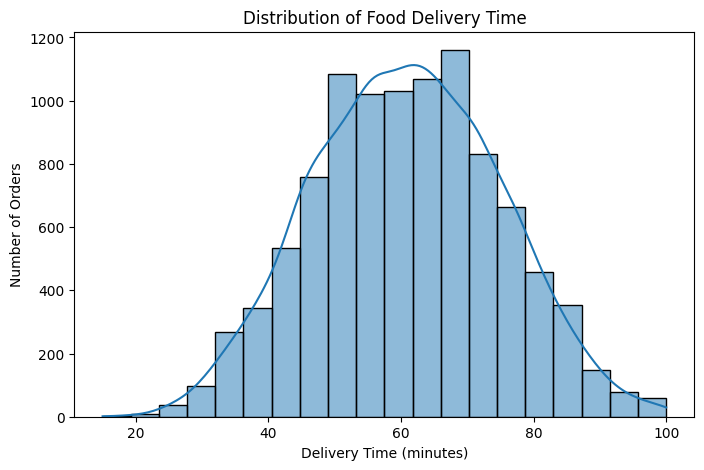

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["Delivery_Time_min"],
    bins=20,
    kde=True
)

plt.title("Distribution of Food Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.show()

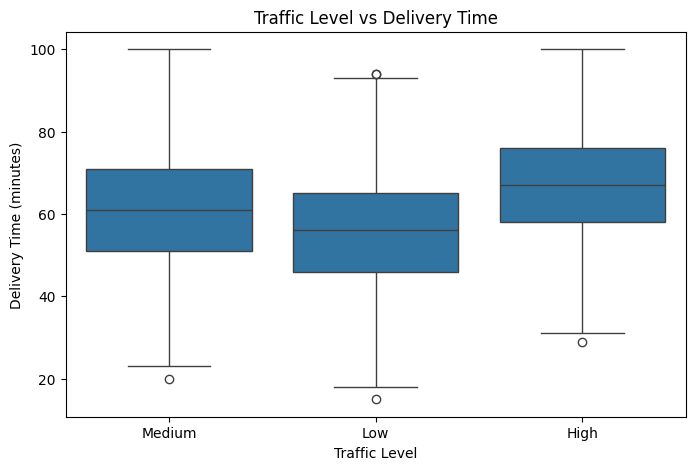

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Traffic_Level",
    y="Delivery_Time_min",
    data=df_clean
)

plt.title("Traffic Level vs Delivery Time")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (minutes)")
plt.show()

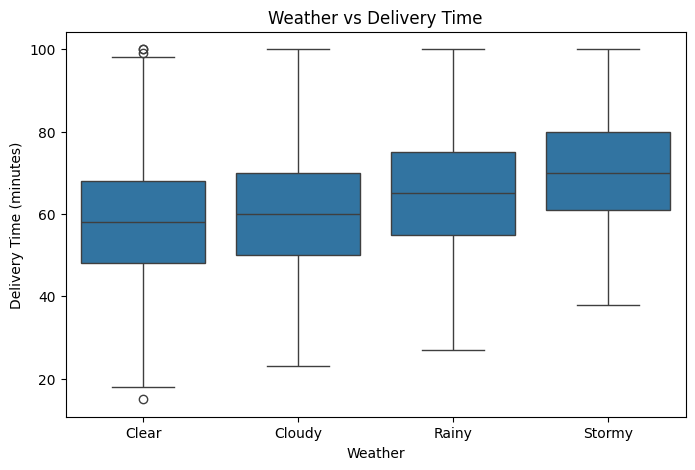

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Weather",
    y="Delivery_Time_min",
    data=df_clean
)

plt.title("Weather vs Delivery Time")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (minutes)")
plt.show()

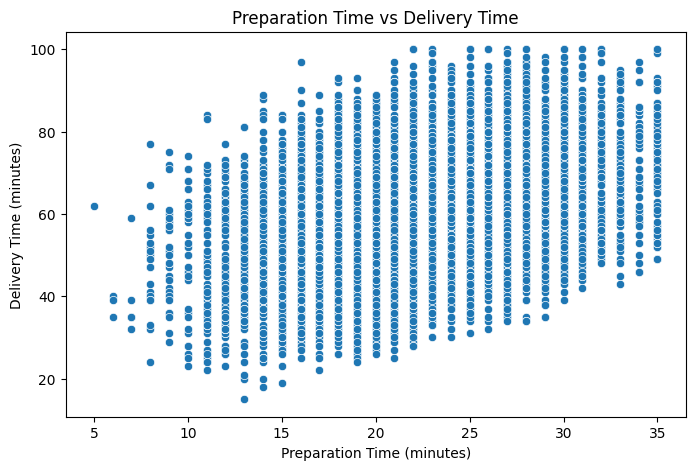

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Preparation_Time_min",
    y="Delivery_Time_min",
    data=df_clean
)

plt.title("Preparation Time vs Delivery Time")
plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

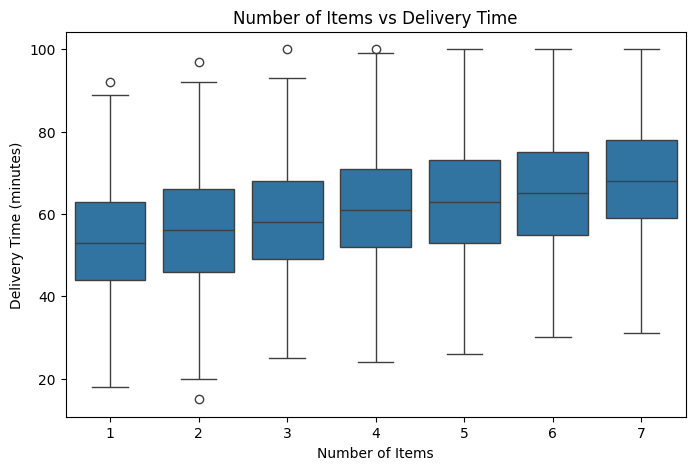

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Number_of_Items",
    y="Delivery_Time_min",
    data=df_clean
)

plt.title("Number of Items vs Delivery Time")
plt.xlabel("Number of Items")
plt.ylabel("Delivery Time (minutes)")
plt.show()

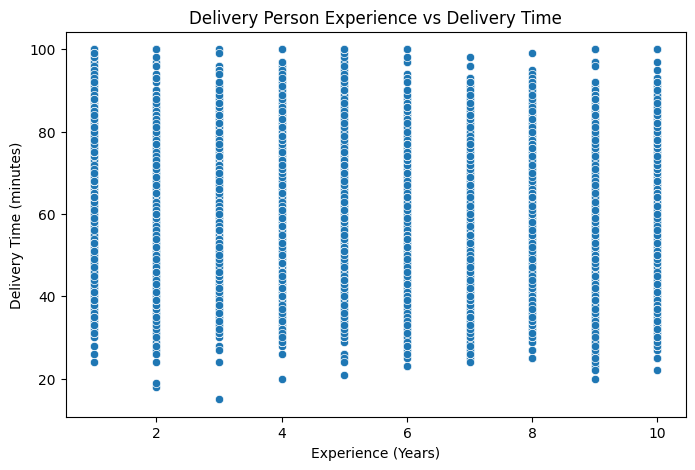

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Delivery_Person_Experience_Years",
    y="Delivery_Time_min",
    data=df_clean
)

plt.title("Delivery Person Experience vs Delivery Time")
plt.xlabel("Experience (Years)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

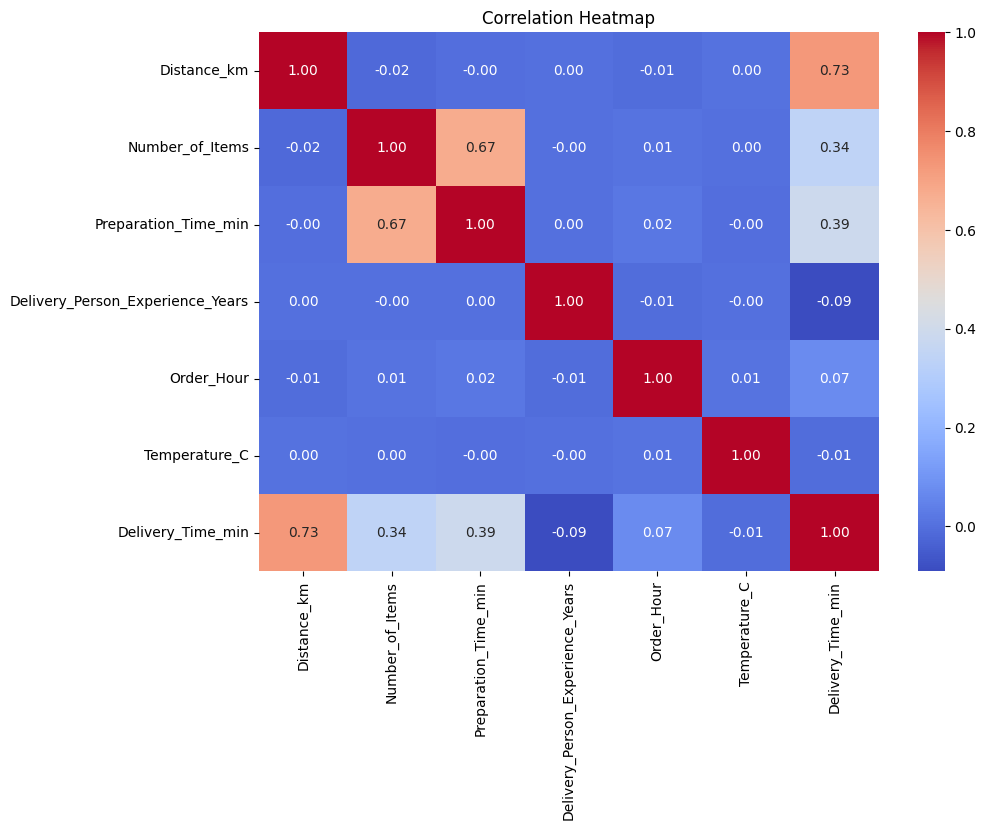

In [ ]:
plt.figure(figsize=(10, 7))

correlation = df_clean.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
target = "Delivery_Time_min"

In [ ]:
print("Target Variable:", target)

Target Variable: Delivery_Time_min


In [ ]:
print("Minimum Delivery Time:", df_clean["Delivery_Time_min"].min())
print("Maximum Delivery Time:", df_clean["Delivery_Time_min"].max())
print("Average Delivery Time:", df_clean["Delivery_Time_min"].mean())

Minimum Delivery Time: 15
Maximum Delivery Time: 100
Average Delivery Time: 60.8187


In [ ]:
df = pd.read_csv("Food_Delivery.csv")
df_clean = df.copy()
print(df_clean.head())
features = [
    "Distance_km",
    "Weather",
    "Traffic_Level",
    "Number_of_Items",
    "Order_Type",
    "Preparation_Time_min",
    "Delivery_Person_Experience_Years",
    "Vehicle_Type",
    "Order_Hour",
    "Day_of_Week",
    "Festival",
    "Temperature_C"
]

X = df_clean[features]
y = df_clean["Delivery_Time_min"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

   Order_ID  Distance_km Weather Traffic_Level  Number_of_Items Order_Type  \
0  FD100000          5.9   Clear        Medium                5     Snacks   
1  FD100001         14.3   Clear           Low                3       Meal   
2  FD100002         11.1   Clear        Medium                6       Meal   
3  FD100003          9.2  Cloudy        Medium                1       Meal   
4  FD100004          2.8  Cloudy        Medium                6     Snacks   

   Preparation_Time_min  Delivery_Person_Experience_Years Vehicle_Type  \
0                    19                                 9          Car   
1                    26                                 9          Car   
2                    35                                 4          Car   
3                    19                                 2      Scooter   
4                    29                                 5      Scooter   

   Order_Hour Day_of_Week Festival  Temperature_C  Delivery_Time_min  
0          14  

In [ ]:
print("Categorical Columns:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nNumerical Columns:")
print(X.select_dtypes(exclude="object").columns.tolist())

Categorical Columns:
['Weather', 'Traffic_Level', 'Order_Type', 'Vehicle_Type', 'Day_of_Week', 'Festival']

Numerical Columns:
['Distance_km', 'Number_of_Items', 'Preparation_Time_min', 'Delivery_Person_Experience_Years', 'Order_Hour', 'Temperature_C']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
        ("num", SimpleImputer(strategy='median'), numerical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 12)
Testing data: (2000, 12)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression model created!")

Linear Regression model created!


In [ ]:
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
linear_predictions = linear_model.predict(X_test)

print("First 10 Predictions:")
print(linear_predictions[:10])

First 10 Predictions:
[59.5112752  72.17412903 73.51788999 27.61445024 60.38507691 59.44678818
 56.36032971 61.86725593 49.21179638 29.84772071]


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("==========================")
print("MAE  :", round(linear_mae, 2))
print("RMSE :", round(linear_rmse, 2))
print("R2   :", round(linear_r2, 2))

Linear Regression Results
MAE  : 3.43
RMSE : 4.32
R2   : 0.91


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42,
            max_depth=10
        ))
    ]
)

print("Decision Tree model created successfully!")

Decision Tree model created successfully!


In [ ]:
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
decision_tree_predictions = decision_tree_model.predict(X_test)

print("First 10 Decision Tree Predictions:")
print(decision_tree_predictions[:10])

First 10 Decision Tree Predictions:
[66.0625     78.19230769 71.49152542 33.09677419 59.28571429 53.39473684
 52.45454545 63.69444444 52.81818182 25.86666667]


In [ ]:
dt_mae = mean_absolute_error(
    y_test,
    decision_tree_predictions
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        decision_tree_predictions
    )
)

dt_r2 = r2_score(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Results")
print("======================")
print("MAE  :", round(dt_mae, 2))
print("RMSE :", round(dt_rmse, 2))
print("R2   :", round(dt_r2, 2))

Decision Tree Results
MAE  : 5.36
RMSE : 6.8
R2   : 0.78


In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            max_depth=10,
            n_jobs=-1
        ))
    ]
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [ ]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
random_forest_predictions = random_forest_model.predict(X_test)

print("First 10 Random Forest Predictions:")
print(random_forest_predictions[:10])

First 10 Random Forest Predictions:
[63.20566076 76.64140773 73.93442557 34.46788263 60.47360727 56.58291485
 55.62756796 64.43752763 51.95175478 28.24825049]


In [ ]:
rf_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        random_forest_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Results")
print("======================")
print("MAE  :", round(rf_mae, 2))
print("RMSE :", round(rf_rmse, 2))
print("R2   :", round(rf_r2, 2))

Random Forest Results
MAE  : 4.25
RMSE : 5.28
R2   : 0.87


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        dt_r2,
        rf_r2
    ]
})

results["MAE"] = results["MAE"].round(2)
results["RMSE"] = results["RMSE"].round(2)
results["R2"] = results["R2"].round(2)

results

,Model,MAE,RMSE,R2
0,Linear Regression,3.43,4.32,0.91
1,Decision Tree,5.36,6.80,0.78
2,Random Forest,4.25,5.28,0.87


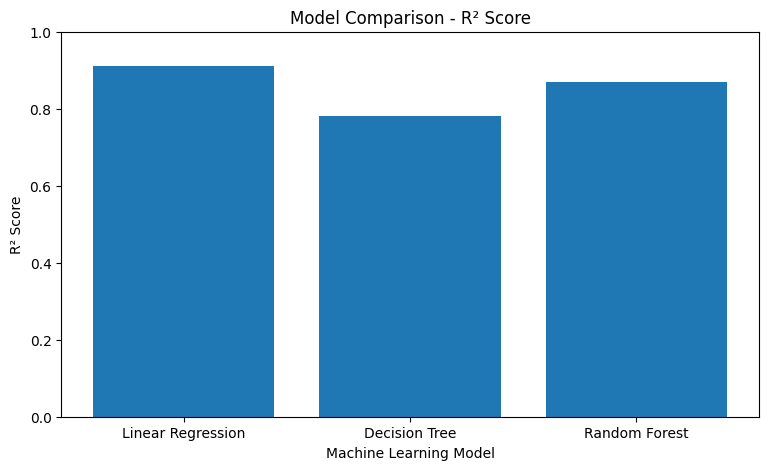

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(results["Model"], results["R2"])

plt.title("Model Comparison - R² Score")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.show()

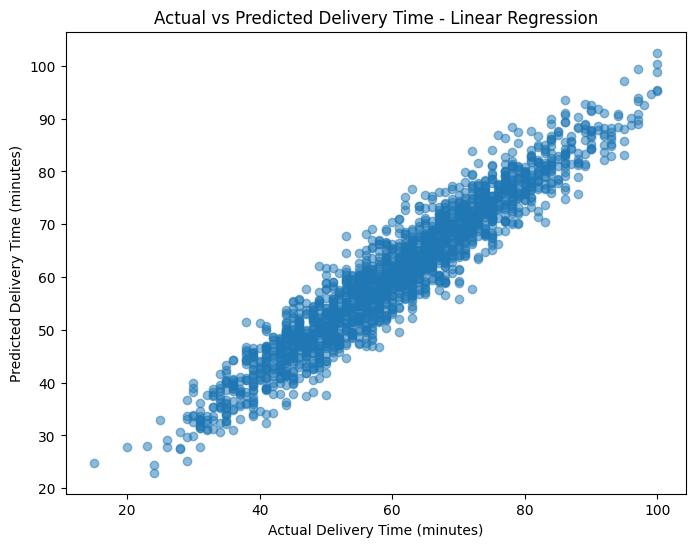

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.5
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time - Linear Regression")

plt.show()

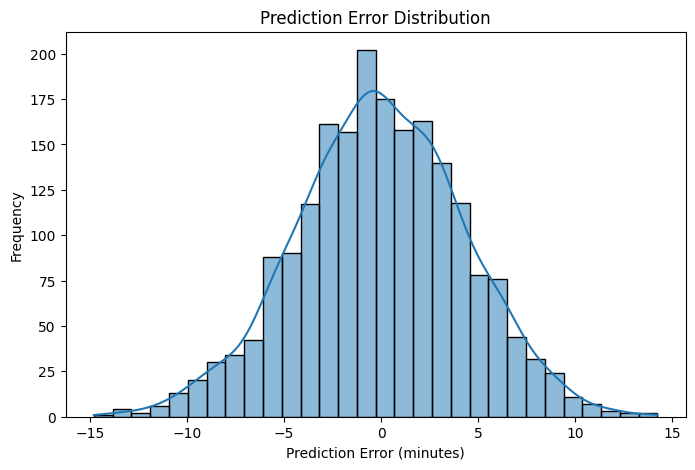

In [ ]:
import seaborn as sns

errors = y_test - linear_predictions

plt.figure(figsize=(8, 5))

sns.histplot(errors, bins=30, kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (minutes)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = linear_model.named_steps["model"].coef_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
3,cat__Weather_Stormy,7.316047,7.316047
4,cat__Traffic_Level_High,6.283306,6.283306
5,cat__Traffic_Level_Low,-5.621488,5.621488
0,cat__Weather_Clear,-5.515115,5.515115
1,cat__Weather_Cloudy,-3.372650,3.372650
16,cat__Day_of_Week_Saturday,2.918932,2.918932
21,cat__Festival_No,-2.556760,2.556760
22,cat__Festival_Yes,2.556760,2.556760
23,num__Distance_km,2.494677,2.494677
12,cat__Vehicle_Type_Car,1.749771,1.749771


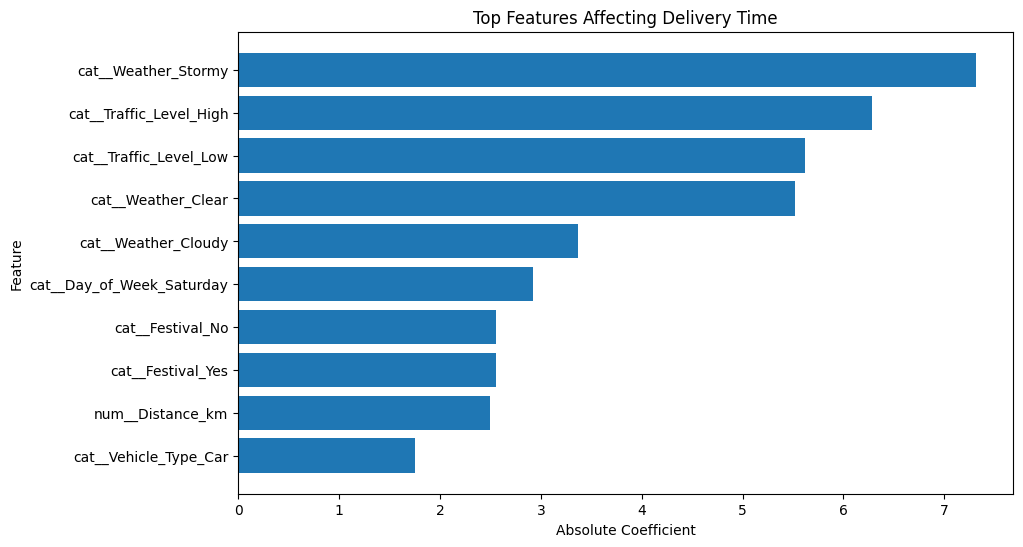

In [ ]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Affecting Delivery Time")

plt.gca().invert_yaxis()

plt.show()

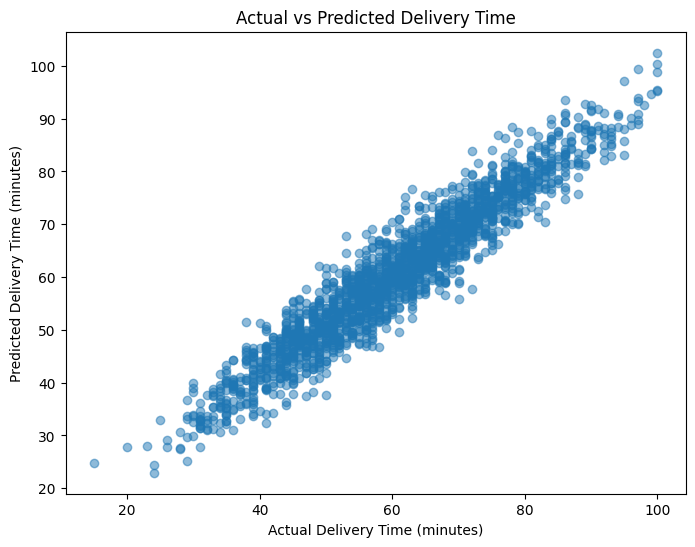

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.5
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

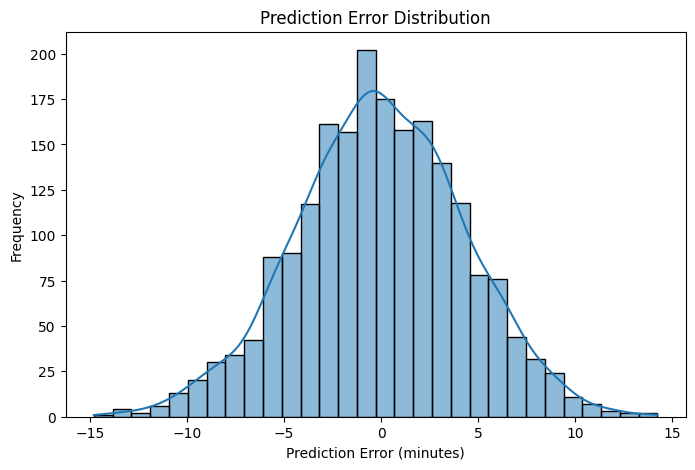

In [ ]:
errors = y_test - linear_predictions

plt.figure(figsize=(8, 5))

sns.histplot(
    errors,
    bins=30,
    kde=True
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (minutes)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
feature_names = (
    linear_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    linear_model
    .named_steps["model"]
    .coef_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
3,cat__Weather_Stormy,7.316047,7.316047
4,cat__Traffic_Level_High,6.283306,6.283306
5,cat__Traffic_Level_Low,-5.621488,5.621488
0,cat__Weather_Clear,-5.515115,5.515115
1,cat__Weather_Cloudy,-3.372650,3.372650
16,cat__Day_of_Week_Saturday,2.918932,2.918932
21,cat__Festival_No,-2.556760,2.556760
22,cat__Festival_Yes,2.556760,2.556760
23,num__Distance_km,2.494677,2.494677
12,cat__Vehicle_Type_Car,1.749771,1.749771


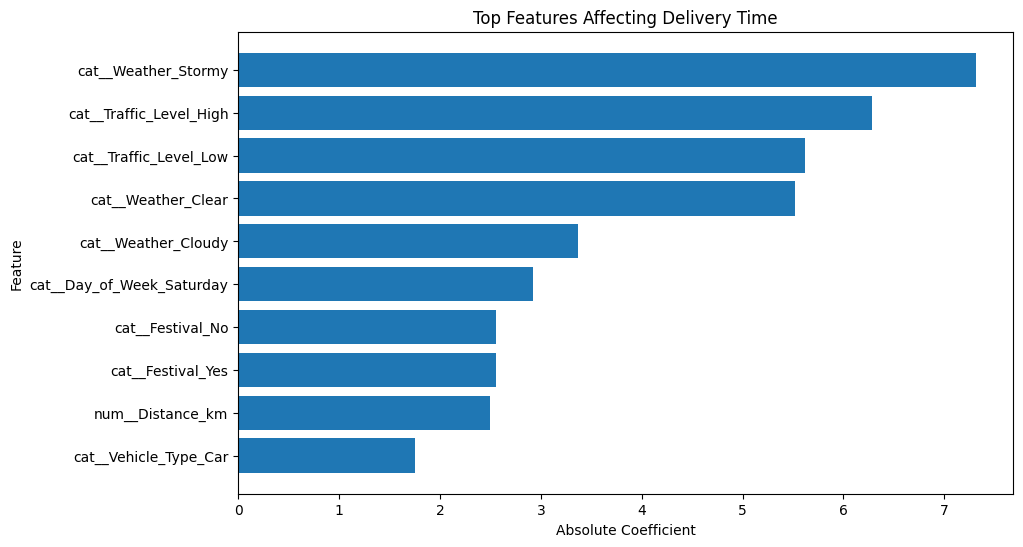

In [ ]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Affecting Delivery Time")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
final_results = results.copy()

print("FINAL MODEL RESULTS")
print("===================")

display(final_results)

FINAL MODEL RESULTS


,Model,MAE,RMSE,R2
0,Linear Regression,3.43,4.32,0.91
1,Decision Tree,5.36,6.80,0.78
2,Random Forest,4.25,5.28,0.87


In [ ]:
new_order = pd.DataFrame({
    "Distance_km": [5.0],
    "Weather": ["Rainy"],
    "Traffic_Level": ["High"],
    "Number_of_Items": [3],
    "Order_Type": ["Meal"],
    "Preparation_Time_min": [18],
    "Delivery_Person_Experience_Years": [4],
    "Vehicle_Type": ["Bike"],
    "Order_Hour": [19],
    "Day_of_Week": ["Saturday"],
    "Festival": ["No"],
    "Temperature_C": [28.0]
})

print("New order details:")
display(new_order)

New order details:


,Distance_km,Weather,Traffic_Level,Number_of_Items,Order_Type,Preparation_Time_min,Delivery_Person_Experience_Years,Vehicle_Type,Order_Hour,Day_of_Week,Festival,Temperature_C
0,5.0,Rainy,High,3,Meal,18,4,Bike,19,Saturday,No,28.0


In [ ]:
predicted_time = linear_model.predict(new_order)[0]

print("===================================")
print(" FOOD DELIVERY TIME PREDICTION")
print("===================================")
print(f"Predicted Delivery Time: {predicted_time:.0f} minutes")

 FOOD DELIVERY TIME PREDICTION
Predicted Delivery Time: 65 minutes


In [ ]:
distance = float(input("Enter delivery distance (km): "))
weather = input("Enter weather (Clear/Cloudy/Rainy/Stormy): ")
traffic = input("Enter traffic level (Low/Medium/High): ")
items = int(input("Enter number of items: "))
order_type = input("Enter order type (Meal/Snacks/Beverages/Dessert): ")
prep_time = int(input("Enter preparation time (minutes): "))
experience = int(input("Enter delivery person's experience (years): "))
vehicle = input("Enter vehicle type (Bike/Scooter/Car): ")
order_hour = int(input("Enter order hour (0-23): "))
day = input("Enter day of week: ")
festival = input("Is it a festival? (Yes/No): ")
temperature = float(input("Enter temperature (°C): "))

In [ ]:
user_order = pd.DataFrame({
    "Distance_km": [distance],
    "Weather": [weather],
    "Traffic_Level": [traffic],
    "Number_of_Items": [items],
    "Order_Type": [order_type],
    "Preparation_Time_min": [prep_time],
    "Delivery_Person_Experience_Years": [experience],
    "Vehicle_Type": [vehicle],
    "Order_Hour": [order_hour],
    "Day_of_Week": [day],
    "Festival": [festival],
    "Temperature_C": [temperature]
})

display(user_order)

In [ ]:
prediction = linear_model.predict(user_order)[0]

print("\n======================================")
print("       FOOD DELIVERY PREDICTION")
print("======================================")
print(f"Predicted Delivery Time: {prediction:.0f} minutes")
print("======================================")

In [ ]:
import joblib

joblib.dump(
    linear_model,
    "food_delivery_prediction_model.pkl"
)

print("Model saved successfully!")

In [ ]:
def predict_delivery_time(
    distance,
    weather,
    traffic,
    items,
    order_type,
    prep_time,
    experience,
    vehicle,
    order_hour,
    day,
    festival,
    temperature
):

    user_order = pd.DataFrame({
        "Distance_km": [distance],
        "Weather": [weather],
        "Traffic_Level": [traffic],
        "Number_of_Items": [items],
        "Order_Type": [order_type],
        "Preparation_Time_min": [prep_time],
        "Delivery_Person_Experience_Years": [experience],
        "Vehicle_Type": [vehicle],
        "Order_Hour": [order_hour],
        "Day_of_Week": [day],
        "Festival": [festival],
        "Temperature_C": [temperature]
    })

    prediction = linear_model.predict(user_order)[0]

    print("\n==========================================")
    print("       FOOD DELIVERY PREDICTION")
    print("==========================================")
    print(f"Distance          : {distance} km")
    print(f"Weather           : {weather}")
    print(f"Traffic           : {traffic}")
    print(f"Number of Items   : {items}")
    print(f"Order Type        : {order_type}")
    print(f"Preparation Time  : {prep_time} min")
    print(f"Experience        : {experience} years")
    print(f"Vehicle           : {vehicle}")
    print(f"Order Hour        : {order_hour}")
    print(f"Day                : {day}")
    print(f"Festival           : {festival}")
    print(f"Temperature        : {temperature} °C")
    print("------------------------------------------")
    print(f"Predicted Delivery Time: {prediction:.0f} minutes")
    print("==========================================")

In [ ]:
predict_delivery_time(
    distance=5.0,
    weather="Rainy",
    traffic="High",
    items=3,
    order_type="Meal",
    prep_time=18,
    experience=4,
    vehicle="Bike",
    order_hour=19,
    day="Saturday",
    festival="No",
    temperature=28.0
)

In [ ]:
valid_weather = ["Clear", "Cloudy", "Rainy", "Stormy"]
valid_traffic = ["Low", "Medium", "High"]
valid_order_type = ["Meal", "Snacks", "Beverages", "Dessert"]
valid_vehicle = ["Bike", "Scooter", "Car"]
valid_days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
valid_festival = ["Yes", "No"]

print("Valid input categories loaded successfully!")

In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE (min)": [
        linear_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE (min)": [
        linear_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        linear_r2,
        dt_r2,
        rf_r2
    ]
})

final_results = final_results.round(2)

display(final_results)

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(final_results["Model"], final_results["MAE (min)"])

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE (minutes)")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(final_results["Model"], final_results["RMSE (min)"])

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (minutes)")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": linear_predictions
})

comparison = comparison.head(50)

plt.figure(figsize=(12, 5))

plt.plot(
    comparison["Actual"].values,
    label="Actual"
)

plt.plot(
    comparison["Predicted"].values,
    label="Predicted"
)

plt.title("Actual vs Predicted Delivery Time")
plt.xlabel("Test Order")
plt.ylabel("Delivery Time (minutes)")
plt.legend()

plt.show()

In [ ]:
final_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully!")

In [ ]:
from IPython.display import display
import ipywidgets as widgets

In [ ]:
# Numeric inputs
distance_widget = widgets.FloatText(
    value=5.0,
    description="Distance (km):"
)

items_widget = widgets.IntText(
    value=3,
    description="Items:"
)

prep_widget = widgets.IntText(
    value=18,
    description="Prep Time:"
)

experience_widget = widgets.IntText(
    value=4,
    description="Experience:"
)

hour_widget = widgets.IntSlider(
    value=19,
    min=0,
    max=23,
    description="Order Hour:"
)

temperature_widget = widgets.FloatText(
    value=28.0,
    description="Temperature:"
)

# Categorical inputs
weather_widget = widgets.Dropdown(
    options=["Clear", "Cloudy", "Rainy", "Stormy"],
    value="Rainy",
    description="Weather:"
)

traffic_widget = widgets.Dropdown(
    options=["Low", "Medium", "High"],
    value="High",
    description="Traffic:"
)

order_type_widget = widgets.Dropdown(
    options=["Meal", "Snacks", "Beverages", "Dessert"],
    value="Meal",
    description="Order Type:"
)

vehicle_widget = widgets.Dropdown(
    options=["Bike", "Scooter", "Car"],
    value="Bike",
    description="Vehicle:"
)

day_widget = widgets.Dropdown(
    options=[
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ],
    value="Saturday",
    description="Day:"
)

festival_widget = widgets.Dropdown(
    options=["No", "Yes"],
    value="No",
    description="Festival:"
)

predict_button = widgets.Button(
    description="Predict Delivery Time",
    button_style="success"
)

output = widgets.Output()

In [ ]:
def make_prediction(button):
    with output:
        output.clear_output()

        user_order = pd.DataFrame({
            "Distance_km": [distance_widget.value],
            "Weather": [weather_widget.value],
            "Traffic_Level": [traffic_widget.value],
            "Number_of_Items": [items_widget.value],
            "Order_Type": [order_type_widget.value],
            "Preparation_Time_min": [prep_widget.value],
            "Delivery_Person_Experience_Years": [
                experience_widget.value
            ],
            "Vehicle_Type": [vehicle_widget.value],
            "Order_Hour": [hour_widget.value],
            "Day_of_Week": [day_widget.value],
            "Festival": [festival_widget.value],
            "Temperature_C": [temperature_widget.value]
        })

        prediction = linear_model.predict(user_order)[0]

        print("==========================================")
        print("       🍔 FOOD DELIVERY PREDICTION")
        print("==========================================")
        print(f"\nPredicted Delivery Time: {prediction:.0f} minutes")
        print("==========================================")

predict_button.on_click(make_prediction)

In [ ]:
display(
    distance_widget,
    weather_widget,
    traffic_widget,
    items_widget,
    order_type_widget,
    prep_widget,
    experience_widget,
    vehicle_widget,
    hour_widget,
    day_widget,
    festival_widget,
    temperature_widget,
    predict_button,
    output
)